# 02 · Ventanas y splits

Apila las ventanas deslizantes, parte el dataset por fecha con embargo, escala
con train y deja `data/processed/ventanas.npz`, que es el único fichero que leen
los cuadernos siguientes.

**Entradas:** `canales.parquet` · `objetivos.parquet` · `regimenes.parquet`

**Salidas:** `data/processed/ventanas.npz`, las figuras de la frontera, del
embargo, del split, del escalado y del reparto, y la tabla de reparto en
`results/metricas/`. La última celda las lista todas con su marca de existencia.

**Qué se decide aquí.** Que el split es temporal y no aleatorio, y que el embargo
se cuenta en sesiones de mercado y no en días naturales. Las dos decisiones se
miden dentro del cuaderno; las cifras las imprimen las celdas, no este texto.

**Tiempo:** es el cuaderno más barato del proyecto. No entrena nada: lo único que
cuesta es apilar las ventanas y escalarlas.

In [1]:
import sys; sys.path.insert(0, "..")   # permite ejecutar desde notebooks/
import src                              # fija el backend de Keras a PyTorch
from src import config, viz
config.fijar_semillas()
viz.aplicar_estilo()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from src import calidad, evaluacion, regimenes, ventanas

config.cargar_catalogo.cache_clear()
nombres = ("train", "validación", "test")

## 1 · La huella de una ventana son 81 sesiones, no 60

Una muestra no ocupa los 60 días de `X`: ocupa también los 21 que describe `Y`.
`X` cubre los 60 días anteriores a `t`, `t` incluido, e `Y` los 21 posteriores:
la huella es `[t−59, t+21]`, 81 sesiones. La celda siguiente imprime esa huella y
la separación mínima que se deduce de ella, y ese número gobierna todo lo demás
del cuaderno.

- Dos ventanas consecutivas comparten 59 de sus 60 días de entrada. El dataset se
  cuenta a sí mismo decenas de veces, y el apartado 8 imprime el factor exacto.
- Para que dos ventanas no compartan ni una sesión tienen que estar separadas por
  al menos 81 posiciones. El 80 del catálogo es el **solape máximo** —las sesiones
  que una ventana puede llegar a compartir con otra—, no la separación. De ahí
  sale el embargo.
- Y de ahí sale que el split tenga que ser temporal. Un `train_test_split`
  aleatorio —lo que hacen los cuadernos guiados del máster— pondría ventanas casi
  idénticas a los dos lados del corte, y las métricas medirían memorización.

In [3]:
canales = pd.read_parquet(src.DIR_PROCESADO / "canales.parquet")
objetivos = pd.read_parquet(src.DIR_PROCESADO / "objetivos.parquet")
tabla_regimenes = pd.read_parquet(src.DIR_PROCESADO / "regimenes.parquet")

v, p = config.ventanas(), config.particiones()
conjunto = ventanas.construir_ventanas(
    canales=canales, regimen_futuro=tabla_regimenes["regimen_futuro"],
    vol_futura=objetivos["vol_futura"], ventanas=v)

print("X:", conjunto.X.shape, "· y_reg:", conjunto.y_reg.shape, "· y_vol:", conjunto.y_vol.shape)
print("De", conjunto.fechas[0].date(), "a", conjunto.fechas[-1].date())
print("Huella de una ventana:", v.pasado, "+", v.horizonte, "=", v.pasado + v.horizonte,
      "sesiones · solape máximo entre dos ventanas:", v.solape_maximo,
      "sesiones · separación mínima para que sean disjuntas:", v.solape_maximo + 1)

X: (5590, 60, 20) · y_reg: (5590,) · y_vol: (5590,)
De 2004-04-27 a 2026-07-16
Huella de una ventana: 60 + 21 = 81 sesiones · solape máximo entre dos ventanas: 80 sesiones · separación mínima para que sean disjuntas: 81


## 2 · El embargo estaba contado en días naturales

El catálogo pedía 85 y la documentación decía "85 **sesiones**". El código lo
aplicaba con `pd.Timedelta(days=85)`, es decir, 85 **días naturales**, y no es lo
mismo: en el calendario de la NYSE 85 días naturales no llegan a las 81 sesiones
que hacen falta. La tabla de abajo mide lo que eso costaba.

- La columna que importa es `sesiones_compartidas`, y tiene que ser cero.
- `auditar_solape` no resta fechas —restar fechas es justamente lo que produjo el
  fallo— sino que construye el conjunto de posiciones que toca cada partición y
  los intersecta.

In [4]:
partes_malas = ventanas.partir_por_dias_naturales(conjunto, p.train_hasta, p.val_hasta, 85)
solape_malo = ventanas.auditar_solape(dict(zip(nombres, partes_malas)), v, canales.index)

print("Embargo aplicado como 85 días naturales:")
solape_malo[["hueco_sesiones", "minimo_exigido", "sesiones_compartidas", "desde", "hasta", "ok"]]

Embargo aplicado como 85 días naturales:


,hueco_sesiones,minimo_exigido,sesiones_compartidas,desde,hasta,ok
frontera,,,,,,
train | validación,59,81,22,2018-12-31,2019-01-31,False
train | test,816,81,0,NaT,NaT,True
validación | test,59,81,22,2021-12-31,2022-02-01,False


## 3 · La frontera, de cerca

**Esta es la figura que va al slide.** Un zoom alrededor del corte
train | validación con la huella `[t−59, t+21]` de las ventanas implicadas en los
tres escenarios. El título lleva las sesiones compartidas de cada uno.

- El split aleatorio no es "un poco peor": mete la misma ventana desplazada un día
  en dos particiones distintas. Es la fuga que producen los cuadernos guiados.
- El embargo en días naturales abre un hueco que no llega al mínimo, y el solape
  que queda es real y contable.
- La frontera validación | test da exactamente lo mismo —mismo hueco, mismo
  solape—, como se ve en la tabla de arriba y en la del apartado 5; por eso no
  se dibuja dos veces.
- El split aleatorio se simula con la semilla del catálogo, y el par de ventanas
  vecinas que se pinta es el que sale de ese sorteo, no uno elegido a mano.
- El split bueno se recalcula aquí en local, con nombres prefijados, porque nace
  más abajo y ninguna figura puede depender de una variable que aún no existe.

In [5]:
_pos = pd.Series(np.arange(len(canales.index)), index=canales.index)
_tr, _va, _te = ventanas.partir(conjunto, p.train_hasta, p.val_hasta, p.embargo_sesiones, v)
_t = int(_pos[_tr.fechas[-1]])
_bueno, _malo = int(_pos[_va.fechas[0]]), int(_pos[partes_malas[1].fechas[0]])

_todas = _pos[conjunto.fechas].to_numpy()
_sorteo = np.random.default_rng(config.semilla()).integers(0, 3, size=len(_todas))
_k = next(k for k in np.argsort(np.abs(_todas - (_t - 12)))
          if k + 1 < len(_todas) and _todas[k + 1] == _todas[k] + 1
          and (_sorteo[k], _sorteo[k + 1]) == (0, 2))
_a, _b = int(_todas[_k]), int(_todas[_k + 1])

In [6]:
def _huella(t):
    return set(range(t - v.pasado + 1, t + v.horizonte + 1))


_filas = [(2, "split aleatorio", (_a, "train", 0), (_b, "test", 2)),
          (1, "embargo · 85 días naturales", (_t, "train", 0), (_malo, "validación", 1)),
          (0, f"embargo · {p.embargo_sesiones} sesiones", (_t, "train", 0), (_bueno, "validación", 1))]
_comp = [len(_huella(x[0]) & _huella(y[0])) for _, _, x, y in _filas]

assert _comp[0] == v.solape_maximo, "el par vecino del sorteo debería compartir el solape máximo"
assert _comp[2] == 0, "el split adoptado no puede compartir ninguna sesión"
print("Sesiones compartidas · aleatorio:", _comp[0], "· 85 días naturales:", _comp[1],
      f"· {p.embargo_sesiones} sesiones:", _comp[2])

Sesiones compartidas · aleatorio: 80 · 85 días naturales: 22 · 85 sesiones: 0


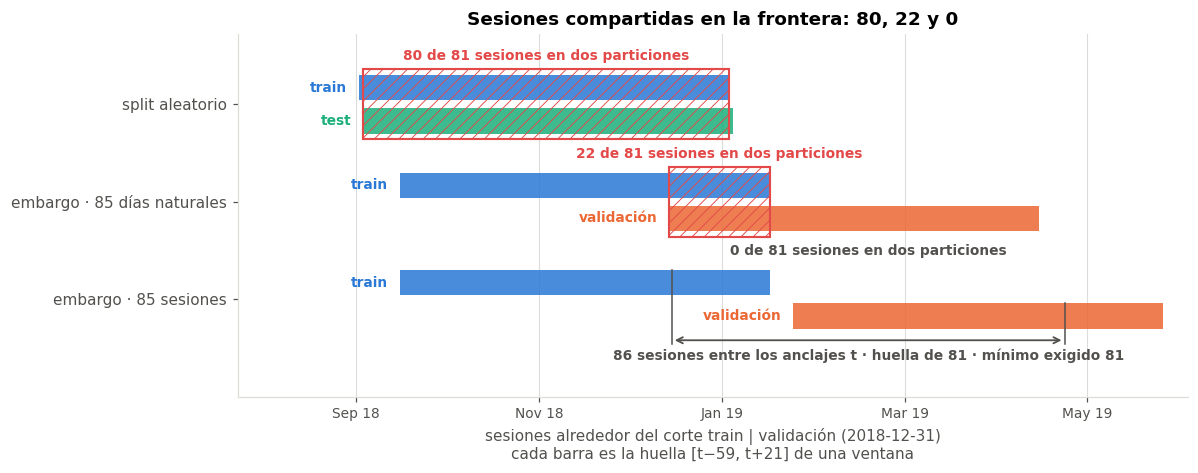

In [7]:
fig, eje = plt.subplots(figsize=(11, 4.4))
_tk = list(range(_a - v.pasado, _bueno + v.horizonte, 40))
eje.set_yticks([f[0] for f in _filas]); eje.set_yticklabels([f[1] for f in _filas], fontsize=10)
eje.set_ylim(-1.0, 2.72); eje.set_xlim(_a - v.pasado - 26, _bueno + v.horizonte + 6)
eje.set_xticks(_tk); eje.set_xticklabels([canales.index[t].strftime("%b %y") for t in _tk], fontsize=9)
eje.set_xlabel(f"sesiones alrededor del corte train | validación ({canales.index[_t].date()})\n"
               f"cada barra es la huella [t−{v.pasado - 1}, t+{v.horizonte}] de una ventana")
eje.set_title("Sesiones compartidas en la frontera: {}, {} y {}".format(*_comp))
eje.grid(False, axis="y")

for (y, etq, *par), n in zip(_filas, _comp):
    for dy, (c, nom, k) in zip((0.17, -0.17), par):
        eje.add_patch(Rectangle((c - v.pasado + 0.5, y + dy - 0.13), v.pasado + v.horizonte, 0.26,
                                facecolor=viz.PALETA[k], alpha=0.85, lw=0))
        eje.text(c - v.pasado - 2, y + dy, nom, ha="right", va="center", fontsize=9,
                 color=viz.PALETA[k], fontweight="bold")
    com = _huella(par[0][0]) & _huella(par[1][0])
    _rotulo = f"{n} de {v.pasado + v.horizonte} sesiones en dos particiones"
    if com:
        eje.add_patch(Rectangle((min(com) - 0.5, y - 0.36), max(com) - min(com) + 1, 0.72,
                                facecolor="none", edgecolor=viz.PALETA[7], hatch="///", lw=1.4, zorder=4))
        eje.text((min(com) + max(com)) / 2, y + 0.42, _rotulo,
                 ha="center", va="bottom", fontsize=9, color=viz.PALETA[7], fontweight="bold")
    else:
        # sin solape no hay recuadro que rotular: el cero se escribe igual que los otros dos,
        # y los anclajes se marcan para que la flecha tenga extremos visibles
        eje.text((par[0][0] + par[1][0]) / 2, y + 0.42, _rotulo,
                 ha="center", va="bottom", fontsize=9, color=viz.TINTA_SECUNDARIA, fontweight="bold")
        for dy, (c, nom, k) in zip((0.17, -0.17), par):
            eje.plot([c, c], [y - 0.46, y + dy + 0.13], color=viz.TINTA_SECUNDARIA, lw=1.0, zorder=5)
        eje.annotate("", xy=(par[0][0], y - 0.42), xytext=(par[1][0], y - 0.42),
                     arrowprops=dict(arrowstyle="<->", color=viz.TINTA_SECUNDARIA, lw=1.2))
        eje.text((par[0][0] + par[1][0]) / 2, y - 0.50,
                 f"{par[1][0] - par[0][0]} sesiones entre los anclajes t · huella de "
                 f"{v.pasado + v.horizonte} · mínimo exigido {v.solape_maximo + 1}",
                 ha="center", va="top", fontsize=9, color=viz.TINTA_SECUNDARIA, fontweight="bold")

viz.guardar(fig, "02_frontera_sin_fuga")

## 4 · Parchear el número o arreglar la unidad

Dos formas de cerrar la fuga, y la tabla decide.

| opción | qué hace |
|---|---|
| subir los días naturales | busca un número que hoy funcione: 119, 125… |
| contar el embargo en sesiones | mide en la unidad correcta |

La columna que decide es **`cortes_cortos_pct`**: el porcentaje de fechas de corte
posibles del panel para las que ese número de días naturales **no llega** al hueco
mínimo. Con 119 no vale cero, y la celda imprime cuánto vale.

- Por coste, 125 días naturales y 85 sesiones son indistinguibles: la celda
  imprime la diferencia exacta de ventanas descartadas. El coste no decide nada.
- Lo que decide es que un embargo que funciona según dónde caigan los festivos es
  una coincidencia, no una garantía.
- Se adopta **85 sesiones**: el valor del catálogo no cambia, cambia la unidad en
  que se lee. El hueco resultante es cierto por construcción, y `partir` ahora
  lanza si el embargo es menor que el solape máximo.

In [8]:
tabla_embargos = ventanas.comparar_embargos(conjunto, p, v, canales.index)

_c125 = int(tabla_embargos.loc["125 días naturales", "descartadas"])
_cses = int(tabla_embargos.loc[f"{p.embargo_sesiones} sesiones", "descartadas"])
print(f"Coste · 125 días naturales descarta {_c125} ventanas y {p.embargo_sesiones} sesiones "
      f"descarta {_cses}: {abs(_c125 - _cses)} de diferencia.")
print(f"Garantía · con 119 días naturales el hueco se queda corto en el "
      f"{tabla_embargos.loc['119 días naturales', 'cortes_cortos_pct']} % de los cortes posibles.")

tabla_embargos

Coste · 125 días naturales descarta 171 ventanas y 85 sesiones descarta 170: 1 de diferencia.
Garantía · con 119 días naturales el hueco se queda corto en el 2.0 % de los cortes posibles.


,train,val,test,descartadas,solape,cortes_cortos_pct
embargo,,,,,,
85 días naturales,3696,699,1079,116,44,100.0
119 días naturales,3696,676,1055,163,0,2.0
125 días naturales,3696,672,1051,171,0,0.0
85 sesiones,3696,672,1052,170,0,0.0


### El mismo embargo, en todos los cortes posibles

La tabla mide el corte concreto de este split. La figura mide **todos** los cortes
del panel: cada franja es el recorrido del hueco que abriría esa opción según
dónde cayera la fecha, y la vertical es el mínimo exigido.

- La lógica de la franja se reimplementa aquí porque la de `ventanas` es privada.
  El `assert` de la celda la reconcilia con `cortes_cortos_pct` **antes** de pintar
  nada: no puede haber dos fuentes de verdad justo debajo de la tabla que decide.
- La opción en sesiones no tiene recorrido: es un punto. Ese es el argumento.

In [9]:
def _huecos_por_dias(indice, dias):
    """Reimplementación inline de ventanas._huecos_por_dias, que es privada."""
    fin = indice + pd.Timedelta(days=dias)
    return (np.searchsorted(indice.to_numpy(), fin.to_numpy(), side="right")
            - np.arange(len(indice)))[fin <= indice[-1]]


_minimo = v.solape_maximo + 1
_opciones = {f"{d} días naturales": _huecos_por_dias(canales.index, d) for d in (85, 119, 125)}
for _n, _h in _opciones.items():
    assert round(100 * float((_h < _minimo).mean()), 1) == tabla_embargos.loc[_n, "cortes_cortos_pct"]
_opciones[f"{p.embargo_sesiones} sesiones"] = np.full(1, p.embargo_sesiones + 1)

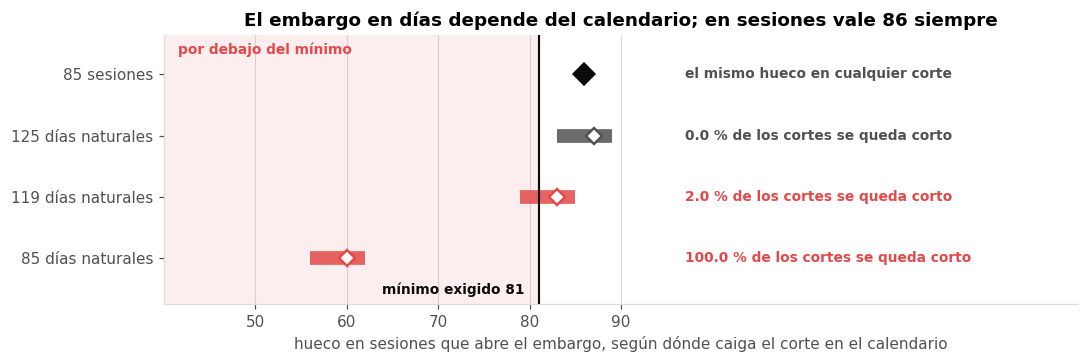

In [10]:
fig, eje = plt.subplots(figsize=(10, 3.4))
eje.axvspan(40, _minimo, color=viz.PALETA[7], alpha=0.09, lw=0)
eje.text(41.5, len(_opciones) - 0.6, "por debajo del mínimo", ha="left", va="center",
         fontsize=9, color=viz.PALETA[7], fontweight="bold")

for _y, (_etq, _h) in enumerate(_opciones.items()):
    _corto = round(100 * float((_h < _minimo).mean()), 1)
    _color = viz.PALETA[7] if _corto else viz.TINTA_SECUNDARIA
    if _h.min() == _h.max():
        # la opción adoptada no tiene recorrido: un rombo sólido, no una línea de longitud cero
        eje.plot([_h.min()], [_y], marker="D", ms=10, color=viz.TINTA_PRIMARIA, zorder=4)
    else:
        eje.plot([_h.min(), _h.max()], [_y, _y], color=_color, lw=9, solid_capstyle="butt", alpha=0.85)
        eje.plot([np.median(_h)], [_y], marker="D", ms=7, color="white", markeredgecolor=_color,
                 mew=1.6, zorder=3)
    eje.text(97, _y, f"{_corto} % de los cortes se queda corto" if len(_h) > 1
             else "el mismo hueco en cualquier corte",
             va="center", fontsize=9, color=_color, fontweight="bold")

eje.axvline(_minimo, color=viz.TINTA_PRIMARIA, lw=1.4, zorder=4)
eje.text(_minimo - 1.5, -0.52, f"mínimo exigido {_minimo}", ha="right", va="center", fontsize=9,
         color=viz.TINTA_PRIMARIA, fontweight="bold")
eje.set_yticks(range(len(_opciones))); eje.set_yticklabels(list(_opciones), fontsize=10)
eje.set_ylim(-0.75, len(_opciones) - 0.35); eje.set_xlim(40, 140); eje.set_xticks([50, 60, 70, 80, 90])
eje.set_xlabel("hueco en sesiones que abre el embargo, según dónde caiga el corte en el calendario")
eje.set_title(f"El embargo en días depende del calendario; en sesiones vale "
              f"{p.embargo_sesiones + 1} siempre")
eje.grid(False, axis="y")
viz.guardar(fig, "02_embargo_en_dias")

## 5 · El split que se adopta

Tres tramos por fecha, cada uno con las crisis que le tocan: train llega a 2018 e
incluye 2008 y 2011; validación es el COVID; test es 2022 en adelante.

- **Validación y test son siempre 100 % reales.** Lo único que cambiará entre las
  versiones del cuaderno 12 es el conjunto de entrenamiento.
- El `assert` de la celda es bloqueante: si alguna sesión cayera en dos
  particiones, el cuaderno para y no se escribe nada.
- El mapa lleva debajo un carril con las rachas contiguas de crisis, en el tono
  oscuro de la rampa de regímenes. A escala de veintidós años el hueco del embargo
  mide medio milímetro; quien quiera verlo tiene la figura de la sección 3, que es
  donde ocupa espacio.

In [11]:
train, val, test = ventanas.partir(conjunto, p.train_hasta, p.val_hasta, p.embargo_sesiones, v)
particion = dict(zip(nombres, (train, val, test)))
solape = ventanas.auditar_solape(particion, v, canales.index)
descartadas = len(conjunto.fechas) - sum(len(x.fechas) for x in particion.values())

for nombre, parte in particion.items():
    print(f"{nombre:<11} {len(parte.fechas):>5} ventanas · {parte.fechas[0].date()} a {parte.fechas[-1].date()}")
print("Descartadas por el embargo:", descartadas)
assert solape["ok"].all(), "Hay sesiones en dos particiones a la vez."

solape[["hueco_sesiones", "minimo_exigido", "sesiones_compartidas", "ok"]]

train        3696 ventanas · 2004-04-27 a 2018-12-31
validación    672 ventanas · 2019-05-06 a 2021-12-31
test         1052 ventanas · 2022-05-05 a 2026-07-16
Descartadas por el embargo: 170


,hueco_sesiones,minimo_exigido,sesiones_compartidas,ok
frontera,,,,
train | validación,86,81,0,True
train | test,843,81,0,True
validación | test,86,81,0,True


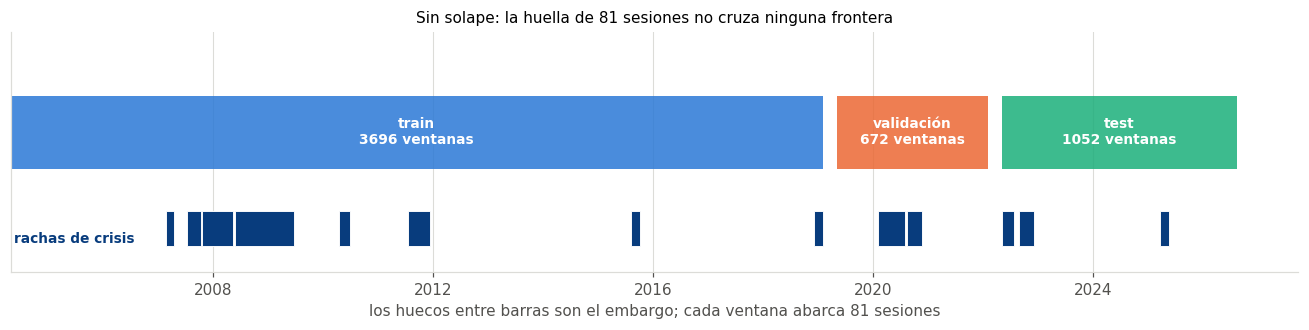

In [12]:
fig, eje = plt.subplots(figsize=(12, 3.1))
viz.carril_particiones(particion, canales.index, v, solape, eje=eje)

_tono = viz.rampa_secuencial(3)[2]
_ind = canales.index
for _parte in particion.values():
    _m = (_parte.y_reg == config.n_regimenes() - 1).astype(int)
    for _i, _j in np.flatnonzero(np.diff(np.r_[0, _m, 0]) != 0).reshape(-1, 2):
        # la racha se extiende hasta el final de la huella de su última ventana,
        # que es la misma convención con la que la barra de encima dibuja la partición
        _fin = _ind[min(_ind.get_loc(_parte.fechas[_j - 1]) + v.horizonte, len(_ind) - 1)]
        eje.barh(-0.72, _fin - _parte.fechas[_i], left=_parte.fechas[_i],
                 height=0.26, color=_tono, edgecolor="white", lw=0.6)

eje.set_ylim(-1.05, 0.75)
eje.text(0.002, 0.12, "rachas de crisis", transform=eje.transAxes, fontsize=9,
         color=_tono, fontweight="bold")
viz.guardar(fig, "split_embargo")

## 6 · Integridad del dataset

Seis controles sobre `X`, `y_reg` e `y_vol`, y ninguno se imputa. Los canales ya
vienen recortados del cuaderno 00 y `construir_ventanas` ya descarta las
posiciones sin objetivo, así que un NaN aquí solo puede venir de un error aguas
arriba, y rellenarlo lo volvería silencioso.

- El control que de verdad se mueve es `clases_pobladas`: mide la pareja
  partición-clase más escasa, que es la crisis de test. La celda imprime cuántas
  ventanas son, y ese número es el que limita todo lo que se pueda concluir.

In [13]:
control = calidad.auditar_ventanas(particion, config.n_regimenes())
print(control.to_string())

                  veredicto  medida  limite                                     donde
control                                                                              
finitud_X                ok       0       0                       sin NaN ni inf en X
finitud_objetivos        ok       0       0                   sin NaN ni inf en y_vol
rango_regimen            ok       0       0                    y_reg dentro de [0, 3)
positividad_vol          ok       0       0                    mínimo de y_vol 0.0347
alineamiento             ok       0       0     longitudes iguales e índice creciente
clases_pobladas          ok     110      30  la más escasa es test/2 con 110 ventanas


## 7 · El escalado se ajusta solo con train

Media y desviación por canal, calculadas **solo con train** y aplicadas a las tres
particiones. Por canal y no por posición temporal: un retorno diario y un z-score
del VIX no son comparables entre sí, pero dentro de un canal todas las posiciones
de la ventana sí lo son.

- Que train dé media 0 y desviación 1 es una identidad algebraica y no prueba
  nada; el `assert` de la celda lo comprueba igualmente, porque un fallo ahí
  significaría que el escalador se ajustó con otra cosa.
- Lo que prueba que el escalador no vio lo que no debía es que **validación y test
  no den 0 y 1**, y eso es lo que afirma el título de la figura.
- De paso, esa misma figura mide el desplazamiento de distribución entre
  particiones, que es lo que acota cuánto se puede extrapolar del cuaderno 12.

In [14]:
media, desviacion = ventanas.ajustar_escalado(train)
escalado = {n: ventanas.escalar(c, media, desviacion) for n, c in particion.items()}

perfil = pd.concat(
    {"media": ventanas.perfil_por_canal(escalado, config.nombres_canales(), "media"),
     "desviación": ventanas.perfil_por_canal(escalado, config.nombres_canales(), "desviacion")},
    axis=1)

assert perfil[("media", "train")].abs().max() < 1e-3, "train no está centrado"
assert (perfil[("desviación", "train")] - 1).abs().max() < 1e-3, "train no tiene desviación 1"

_orden = perfil["media"][["validación", "test"]].abs().max(axis=1).sort_values(ascending=False)
print("Desplazamiento de la media tras escalar · máximo sobre validación y test, canal a canal (de 20):")
print(perfil["media"].loc[_orden.index[:4], ["validación", "test"]].round(2).to_string())
print(f"Los otros {len(_orden) - 4} canales no pasan de {_orden.iloc[4]:.2f}.")

Desplazamiento de la media tras escalar · máximo sobre validación y test, canal a canal (de 20):
                   validación  test
corr_accion_bono         0.15  1.55
pendiente_curva_z        0.85 -1.32
spread_credito_z         1.10  1.16
drawdown_sp500           0.50  0.23
Los otros 16 canales no pasan de 0.41.


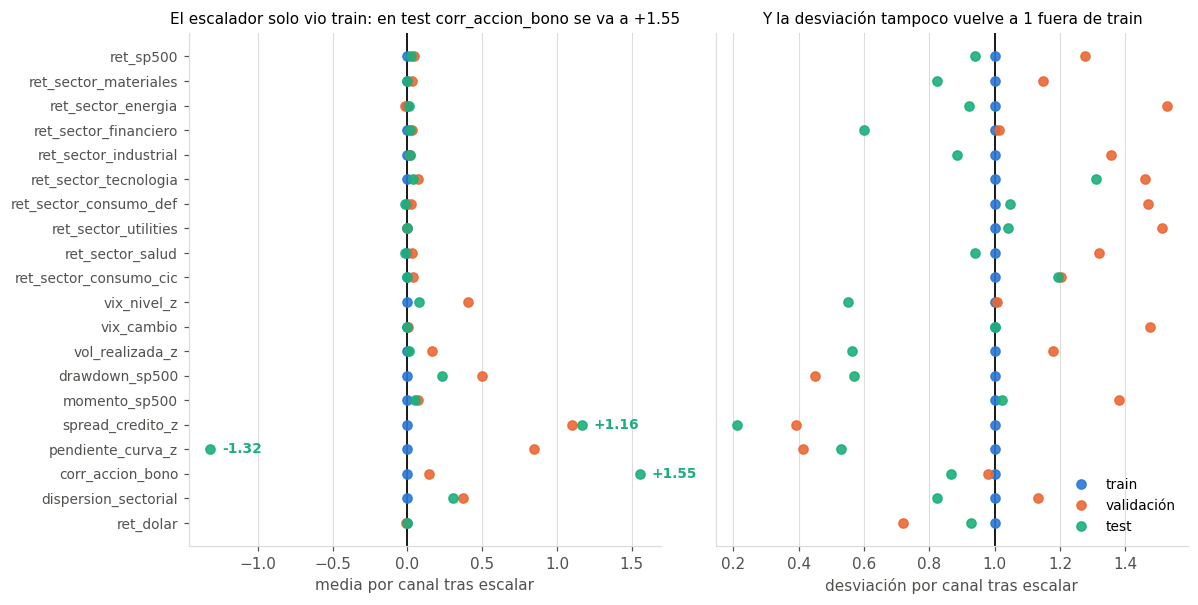

In [15]:
_y = np.arange(len(perfil))[::-1]
_destacados = _orden.head(3).index
fig, ejes = plt.subplots(1, 2, figsize=(11, 5.6), sharey=True)

for _eje, _est, _ref in ((ejes[0], "media", 0.0), (ejes[1], "desviación", 1.0)):
    _eje.axvline(_ref, color=viz.TINTA_PRIMARIA, lw=1.2)
    for _k, _n in enumerate(nombres):
        _eje.plot(perfil[(_est, _n)].to_numpy(), _y, ls="none", marker="o", ms=6,
                  color=viz.PALETA[_k], alpha=0.9, label=_n, zorder=3)
    _eje.grid(False, axis="y")
    _eje.set_xlabel(f"{_est} por canal tras escalar")

for _canal in _destacados:
    ejes[0].annotate(f"{perfil[('media', 'test')].loc[_canal]:+.2f}",
                     xy=(perfil[("media", "test")].loc[_canal], _y[list(perfil.index).index(_canal)]),
                     xytext=(8, 0), textcoords="offset points", va="center", fontsize=9,
                     color=viz.PALETA[2], fontweight="bold")

_peor = perfil[("media", "test")].abs().idxmax()
ejes[0].set_yticks(_y); ejes[0].set_yticklabels(perfil.index, fontsize=9)
ejes[0].set_title(f"El escalador solo vio train: en test {_peor} se va a "
                  f"{perfil[('media', 'test')].loc[_peor]:+.2f}", fontsize=10, fontweight="normal")
ejes[1].set_title("Y la desviación tampoco vuelve a 1 fuera de train", fontsize=10, fontweight="normal")
ejes[1].legend(loc="lower right", fontsize=9)
ejes[1].tick_params(axis="y", length=0)
viz.guardar(fig, "02_escalador_solo_train")

## 8 · Qué se lleva cada partición

**El reparto de clases no es el mismo en las tres**, y eso condiciona cómo se leen
los resultados: dos generadores medidos sobre particiones con distinto balance no
son directamente comparables.

- El número que limita cualquier intervalo de confianza no es el de ventanas de
  crisis sino el de **rachas contiguas**. De ahí sale D21 (`docs/DECISIONES.md`,
  bootstrap de bloques de 81 sesiones): ninguna diferencia de recall de crisis
  menor de unos 20 puntos es distinguible del ruido.
- La última racha de crisis de train está **censurada** por la frontera del split:
  termina donde termina train y continúa dentro del embargo. Y la primera de test
  lo está por el otro lado, porque la primera ventana de test ya es crisis: esa
  racha empezó dentro del embargo. Es el caso que más importa, porque las ventanas
  de crisis de test son la base de la banda de D21. Contarlas enteras exageraría
  el tamaño muestral, nunca al revés.
- Estas rachas se cuentan sobre ventanas y sobre la etiqueta del HMM. **No son los
  episodios de estrés del cuaderno 00**, que son rachas de `vix_nivel_z > 2`
  fusionadas sobre la muestra completa: cuentan objetos distintos y no se
  reconcilian.
- Los bloques disjuntos admiten dos convenciones y la celda imprime las dos. La
  que publican D20 (una sola arquitectura downstream, congelada), D21 y el README
  cuenta **ventanas**: `len(parte) // 81`. La otra aplica ese mismo `// 81` a las
  **sesiones de calendario** que cubre el tramo, no a los anclajes de ventana. No
  se reconcilian: miden cosas distintas.

In [16]:
reparto = pd.DataFrame(
    {n: regimenes.distribucion(c.y_reg, config.n_regimenes())["porcentaje"] for n, c in particion.items()})
reparto.index = evaluacion.nombres_regimenes(config.n_regimenes())

print("Reparto de clases, en % de ventanas:")
print(reparto.round(1).to_string())

Reparto de clases, en % de ventanas:
            train  validación  test
calma        54.6        18.3  33.0
transición   29.5        59.7  56.6
crisis       15.9        22.0  10.5


In [17]:
rachas = {n: regimenes.tramos_contiguos(c.y_reg, config.n_regimenes() - 1) for n, c in particion.items()}
_crisis = {n: int((c.y_reg == config.n_regimenes() - 1).sum()) for n, c in particion.items()}

print("Ventanas de crisis y rachas contiguas ·",
      " · ".join(f"{n}: {_crisis[n]} en {rachas[n]} rachas" for n in nombres))

Ventanas de crisis y rachas contiguas · train: 587 en 8 rachas · validación: 148 en 2 rachas · test: 110 en 3 rachas


In [18]:
_huella_ses = v.pasado + v.horizonte
for n, c in particion.items():
    # fija la convención de `src`: si cambiara el cálculo de bloques_disjuntos, salta aquí
    assert int(ventanas.tamano_muestral_efectivo(c.fechas, v)["bloques_disjuntos"]) == len(c.fechas) // _huella_ses

print("Bloques disjuntos, contando ventanas (len // {}), que es lo que publican D20, D21 y el README ·".format(_huella_ses),
      " · ".join(f"{n}: {len(c.fechas) // _huella_ses}" for n, c in particion.items()))
print("Bloques disjuntos, aplicando ese mismo len // {} a las sesiones de calendario del tramo ·".format(_huella_ses),
      " · ".join(f"{n}: {(len(c.fechas) + v.solape_maximo) // _huella_ses}" for n, c in particion.items()))
print(f"Cada bloque disjunto de train reúne {len(train.fechas) / (len(train.fechas) // _huella_ses):.1f} "
      f"ventanas: ese es el factor con el que el dataset se cuenta a sí mismo.")

Bloques disjuntos, contando ventanas (len // 81), que es lo que publican D20, D21 y el README · train: 45 · validación: 8 · test: 12
Bloques disjuntos, aplicando ese mismo len // 81 a las sesiones de calendario del tramo · train: 46 · validación: 9 · test: 13
Cada bloque disjunto de train reúne 82.1 ventanas: ese es el factor con el que el dataset se cuenta a sí mismo.


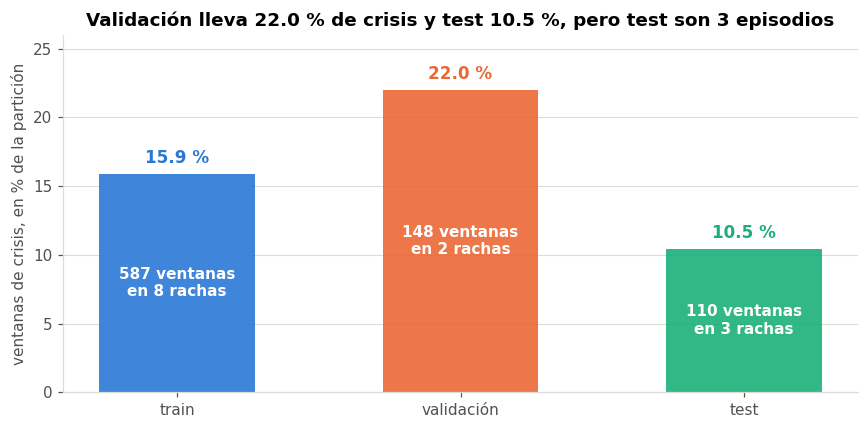

In [19]:
fig, eje = plt.subplots(figsize=(8, 4.0))
_pct = {n: float(reparto.loc["crisis", n]) for n in nombres}
eje.bar(np.arange(3), [_pct[n] for n in nombres], width=0.55,
        color=[viz.PALETA[k] for k in range(3)], alpha=0.9)

for _k, _n in enumerate(nombres):
    eje.text(_k, _pct[_n] + 0.5, f"{_pct[_n]:.1f} %", ha="center", va="bottom", fontsize=11,
             fontweight="bold", color=viz.PALETA[_k])
    eje.text(_k, _pct[_n] / 2, f"{_crisis[_n]} ventanas\nen {rachas[_n]} rachas", ha="center",
             va="center", fontsize=10, fontweight="bold", color="white")

eje.set_xticks(np.arange(3)); eje.set_xticklabels(nombres, fontsize=10)
eje.set_ylim(0, max(_pct.values()) + 4)
eje.set_ylabel("ventanas de crisis, en % de la partición")
eje.set_title(f"Validación lleva {_pct['validación']:.1f} % de crisis y test {_pct['test']:.1f} %, "
              f"pero test son {rachas['test']} episodios")
eje.grid(False, axis="x")
viz.guardar(fig, "02_prevalencia_y_rachas")

## 9 · El bloque que consumen los generadores

No es `X`: es `[X aplanada ‖ y_vol]`, de forma que cada muestra sintética viene
con su objetivo de regresión coherente.

- El régimen va aparte, como condición, para poder sobre-generar la clase de
  crisis —que es el objetivo del taller— en vez de replicar el desbalance.
- La dimensión sale de `ventanas.dimension_bloque` y la celda la comprueba contra
  la forma real del bloque antes de seguir.

In [20]:
bloque = ventanas.empaquetar(escalado["train"])
assert bloque.shape[1] == ventanas.dimension_bloque(v)

print("Bloque para los generadores:", bloque.shape,
      f"= {v.pasado} x {config.n_canales()} + 1")

Bloque para los generadores: (3696, 1201) = 60 x 20 + 1


## Qué se lleva el resto del proyecto

- **`ventanas.npz`**, con las tres particiones ya escaladas y el escalador. Es lo
  único que abren los cuadernos 03 a 14.
- **Un split sin solape**, verificado por conteo de posiciones y no por resta de
  fechas.
- **El bloque que modelan los siete generadores**, con la dimensión que imprime la
  celda anterior.
- **Las rachas contiguas de crisis**, que son el tamaño muestral honesto para
  cualquier barra de error sobre la clase minoritaria.

Y una distinción que se confunde a menudo: lo que se mide en este cuaderno es
**fuga del split**, es decir, posiciones del panel compartidas entre particiones
reales. No es lo que mide D16 (`docs/DECISIONES.md`), que es la **memorización del
generador**, por distancia al vecino más cercano sobre una proyección PCA de 50
componentes del bloque, porque en las 1201 dimensiones crudas todas las distancias
convergen y el vecino más cercano deja de significar nada. Un split limpio no
garantiza un generador que no copie, y un generador que no copia no arregla un
split contaminado.

## Salidas generadas

In [21]:
from pathlib import Path
import hashlib

_npz = src.DIR_PROCESADO / ventanas.NOMBRE_PROCESADO
_antes = {}
if _npz.exists():
    _previo = np.load(_npz)
    _antes = {k: hashlib.md5(np.ascontiguousarray(_previo[k]).tobytes()).hexdigest() for k in _previo.files}
    _previo.close()

src.DIR_METRICAS.mkdir(parents=True, exist_ok=True)
ruta = ventanas.guardar_procesado(ventanas.Particion(
    train=escalado["train"], val=escalado["validación"], test=escalado["test"],
    media=media, desviacion=desviacion))
reparto.round(2).to_csv(src.DIR_METRICAS / "reparto_particiones.csv")

In [22]:
_ahora = np.load(ruta)
_despues = {k: hashlib.md5(np.ascontiguousarray(_ahora[k]).tobytes()).hexdigest() for k in _ahora.files}
_ahora.close()
_cambiados = sorted(k for k in _despues if _antes.get(k) != _despues[k])

if not _antes:
    print("No había ventanas.npz previo: nada que comparar.")
elif _cambiados:
    print("AVISO · estos arrays de ventanas.npz cambian respecto al fichero anterior:",
          ", ".join(_cambiados), "· los bancos sintéticos de data/synthetic/ hay que regenerarlos.")
else:
    print("ventanas.npz reproduce array a array el fichero anterior · los bancos "
          "sintéticos ya generados siguen siendo válidos.")

ventanas.npz reproduce array a array el fichero anterior · los bancos sintéticos ya generados siguen siendo válidos.


In [23]:
salidas = [ruta, src.DIR_METRICAS / "reparto_particiones.csv",
           *(src.DIR_FIGURAS / f"{n}.png" for n in
             ("02_frontera_sin_fuga", "02_embargo_en_dias", "split_embargo",
              "02_escalador_solo_train", "02_prevalencia_y_rachas"))]

for r in salidas:
    r = Path(r)
    print("[{}] {}".format("ok" if r.exists() else "--", r.relative_to(src.RAIZ)))

[ok] data\processed\ventanas.npz
[ok] results\metricas\reparto_particiones.csv
[ok] results\figures\02_frontera_sin_fuga.png
[ok] results\figures\02_embargo_en_dias.png
[ok] results\figures\split_embargo.png
[ok] results\figures\02_escalador_solo_train.png
[ok] results\figures\02_prevalencia_y_rachas.png


In [24]:
print("Lo que este cuaderno entrega")
print(f"· {len(conjunto.fechas)} ventanas de {v.pasado} x {config.n_canales()} canales, repartidas en "
      f"{len(train.fechas)} / {len(val.fechas)} / {len(test.fechas)} y {descartadas} descartadas por el embargo")
print(f"· {int(solape['sesiones_compartidas'].sum())} sesiones en dos particiones a la vez, con un hueco de "
      f"{int(solape.loc['train | validación', 'hueco_sesiones'])} sesiones frente al mínimo de {v.solape_maximo + 1}")
print(f"· un bloque de {bloque.shape[1]} dimensiones y las rachas de crisis "
      f"{rachas['train']} / {rachas['validación']} / {rachas['test']}, que son el tamaño muestral honesto")

Lo que este cuaderno entrega
· 5590 ventanas de 60 x 20 canales, repartidas en 3696 / 672 / 1052 y 170 descartadas por el embargo
· 0 sesiones en dos particiones a la vez, con un hueco de 86 sesiones frente al mínimo de 81
· un bloque de 1201 dimensiones y las rachas de crisis 8 / 2 / 3, que son el tamaño muestral honesto
